In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import missingno as msno 

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.neighbors import KNeighborsClassifier as KNNC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB

In [118]:
df = pd.read_csv("Data/Telco_customer_churn.csv")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [119]:
display(df.head())

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [120]:
print(df.shape)

(7043, 33)


In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [122]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [123]:
df = df.astype({col: object for col in df.select_dtypes(include='string').columns})

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 non-null   

In [125]:
df["Total Charges"] = df["Total Charges"].replace(" ","0")
df["Total Charges"] = df["Total Charges"].astype("float")

In [126]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [127]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [128]:
df.rename(columns={'Churn Label': 'Churn'}, inplace=True)

<Axes: >

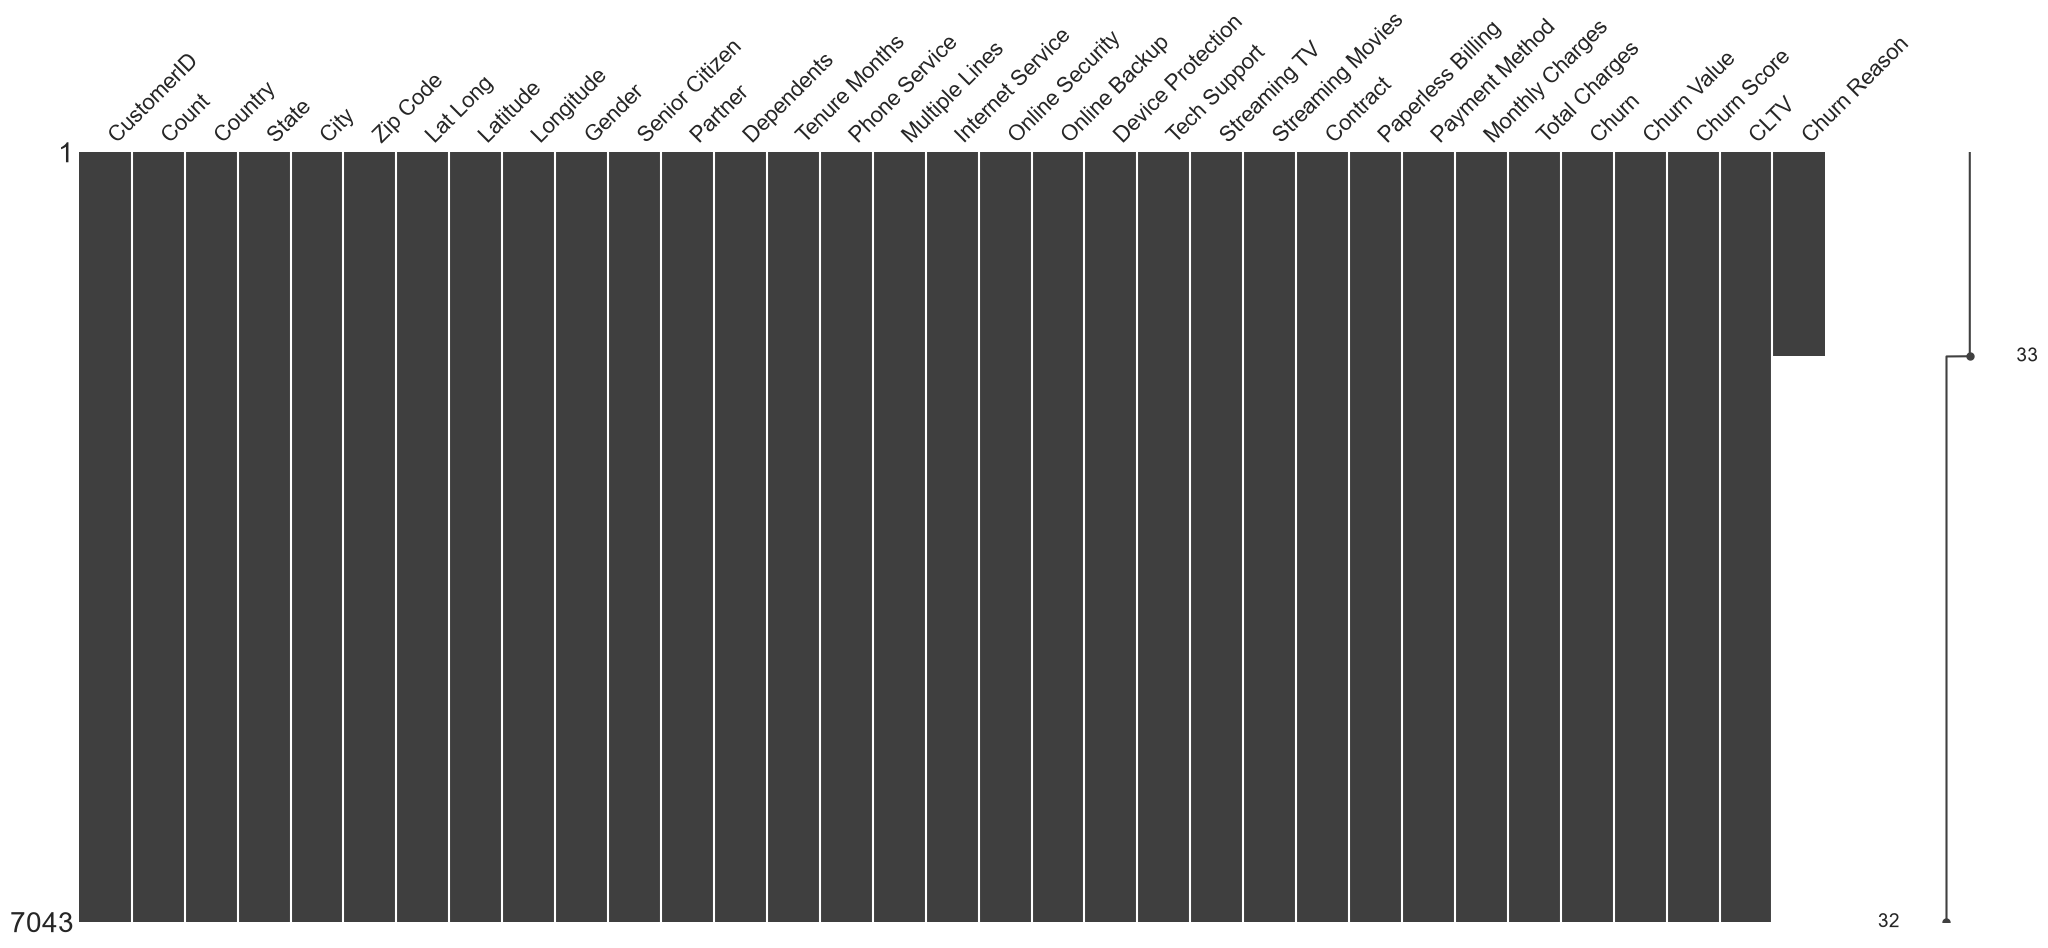

In [129]:
msno.matrix(df)

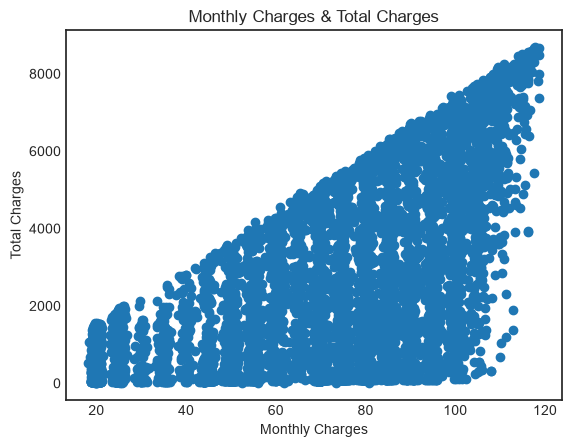

In [130]:
plt.scatter(df["Monthly Charges"], df["Total Charges"])
plt.title("Monthly Charges & Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

In [131]:
Payment_Method = df.groupby("Payment Method").sum()["CLTV"]
Payment_Method

Payment Method
Bank transfer (automatic)     7126759
Credit card (automatic)       6968139
Electronic check             10128516
Mailed check                  6767869
Name: CLTV, dtype: int64

<Axes: xlabel='Payment Method'>

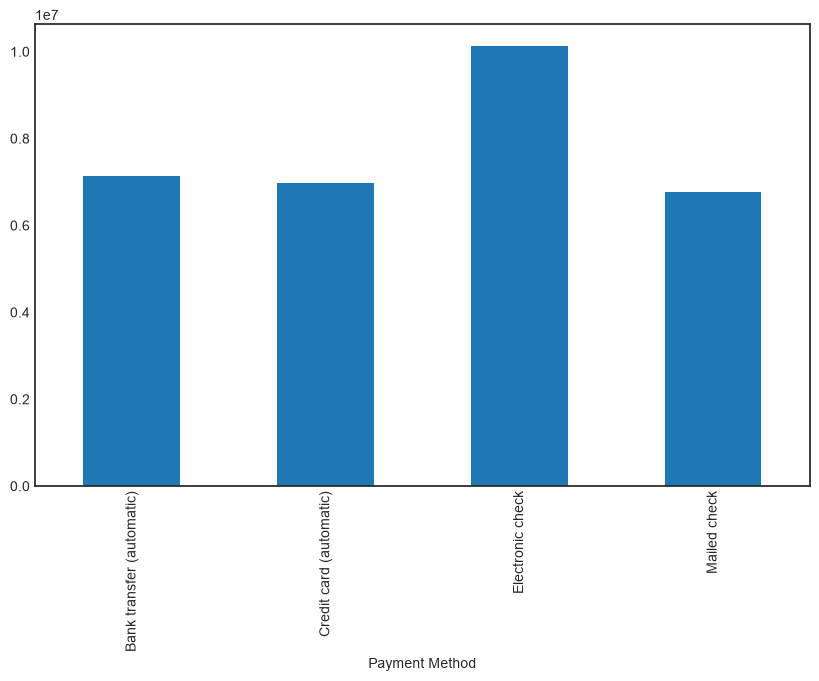

In [132]:
Payment_Method.plot.bar(x='Payment Method', y='CLTV', figsize=(10,6))

<Axes: xlabel='CLTV', ylabel='Contract'>

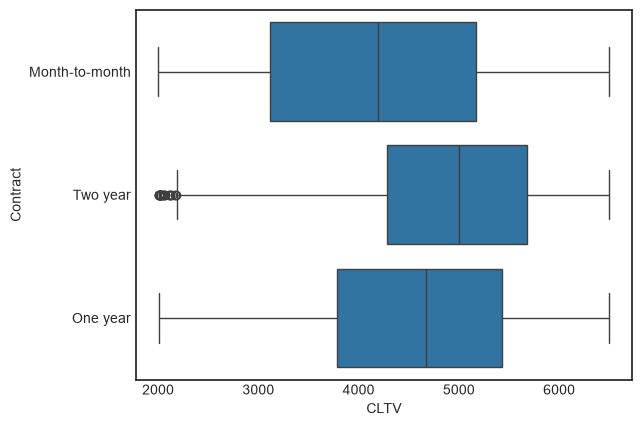

In [133]:
sns.boxplot( y=df["Contract"], x=df["CLTV"] )

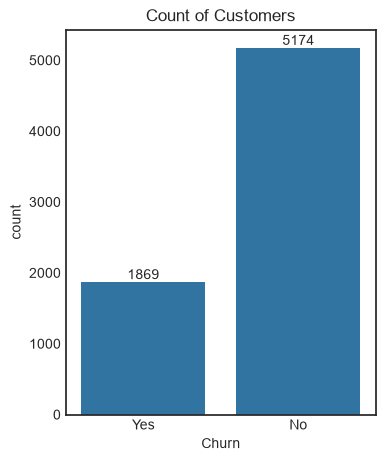

In [134]:
plt.figure(figsize = (4,5))
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers")
plt.show()

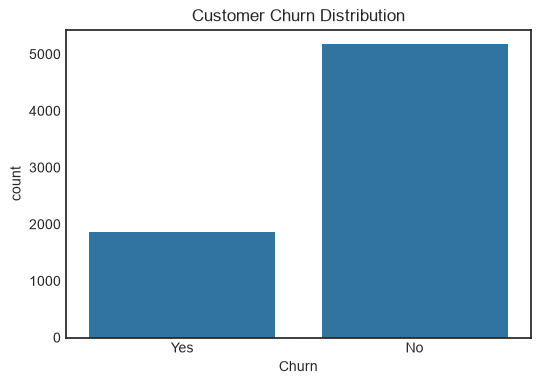

In [135]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.show()

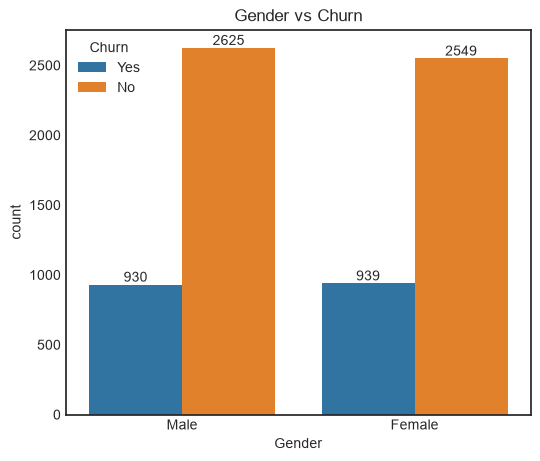

In [136]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='Gender', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Gender vs Churn")
plt.show()

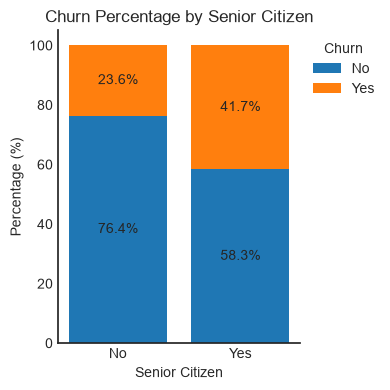

In [137]:
data_counts = df.groupby(['Senior Citizen', 'Churn']).size().unstack(fill_value=0)

data_percent = data_counts.div(data_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(4,4))
bottom = [0, 0]

for idx, column in enumerate(data_percent.columns):
    ax.bar(data_percent.index, data_percent[column], bottom=bottom, label=column)
    
    for i, val in enumerate(data_percent[column]):
        if val > 0:
            ax.text(i, bottom[i] + val / 2, f'{val:.1f}%', ha='center', va='center', fontsize=10)
    bottom = [i + j for i, j in zip(bottom, data_percent[column])]

ax.set_title("Churn Percentage by Senior Citizen")
ax.set_xlabel("Senior Citizen")
ax.set_ylabel("Percentage (%)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])
ax.legend(title="Churn", bbox_to_anchor = (1,1))
sns.despine()
plt.tight_layout()
plt.show()

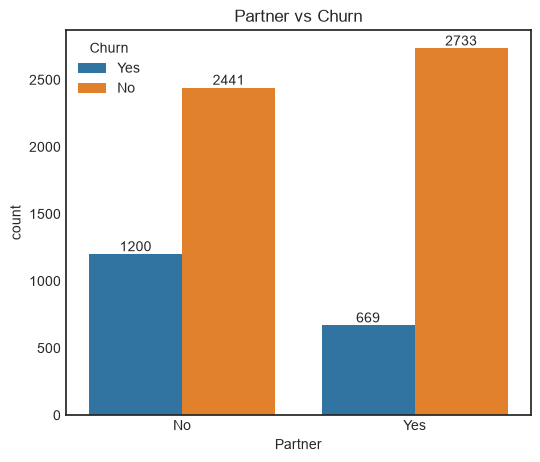

In [138]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='Partner', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Partner vs Churn")
plt.show()

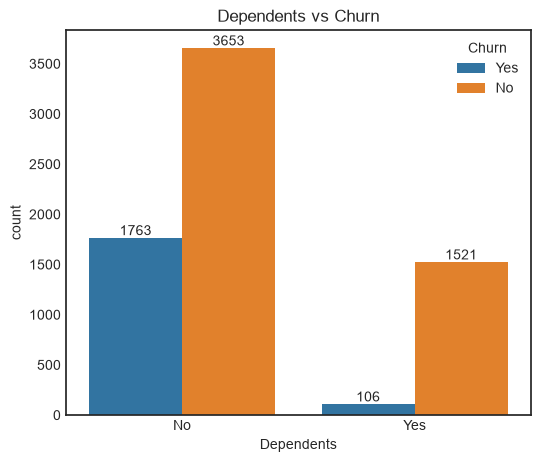

In [139]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='Dependents', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Dependents vs Churn")
plt.show()

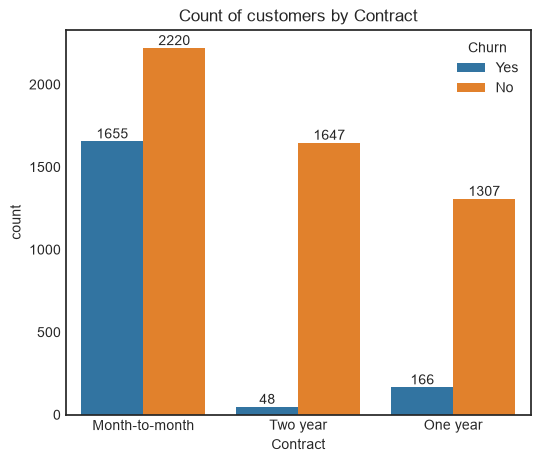

In [140]:
plt.figure(figsize = (6,5))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of customers by Contract")
plt.show()

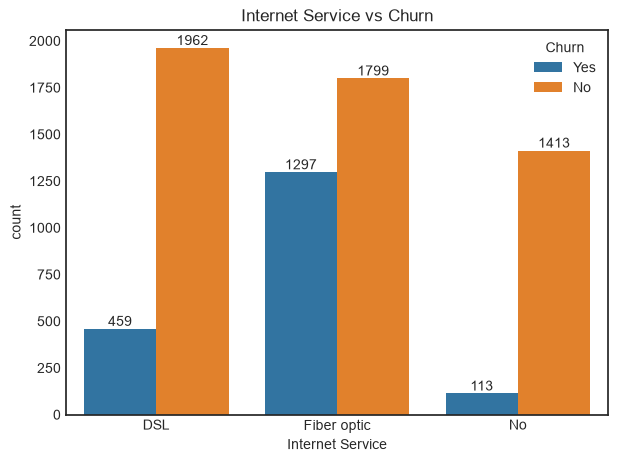

In [141]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='Internet Service', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Internet Service vs Churn")
plt.show()

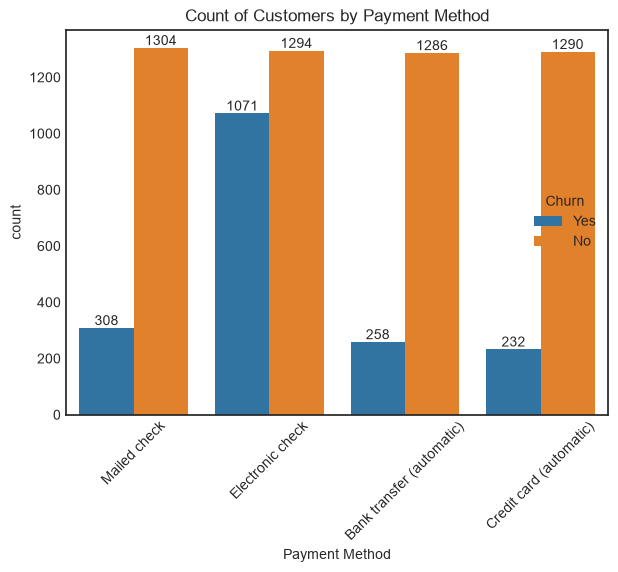

In [142]:
plt.figure(figsize = (7,5))
ax = sns.countplot(x = "Payment Method", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

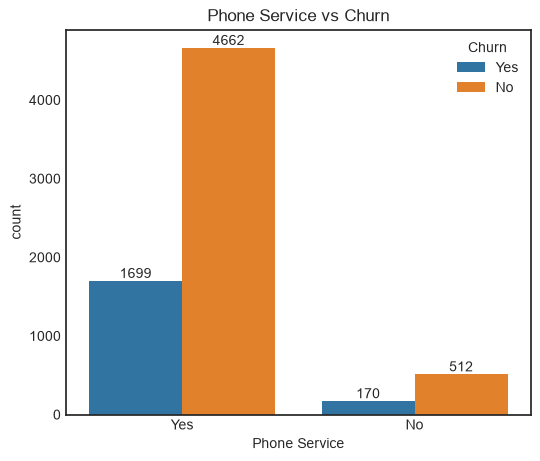

In [143]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='Phone Service', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Phone Service vs Churn")
plt.show()

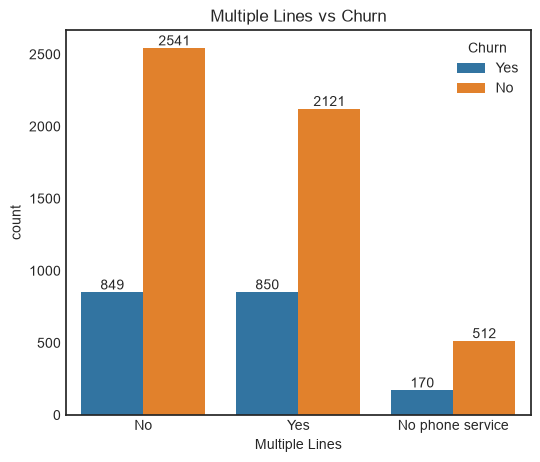

In [144]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='Multiple Lines', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Multiple Lines vs Churn")
plt.show()

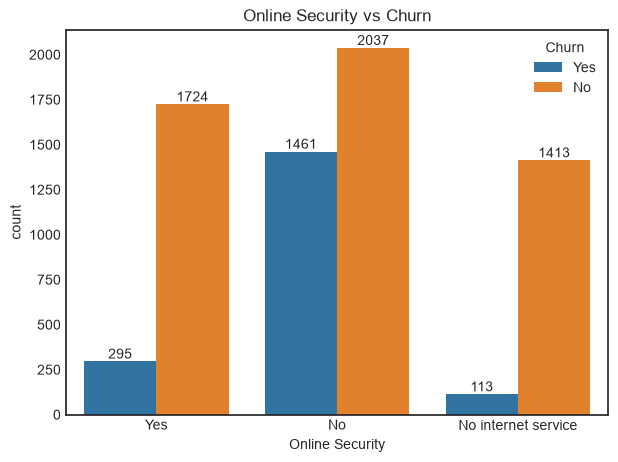

In [145]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='Online Security', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Online Security vs Churn")
plt.show()

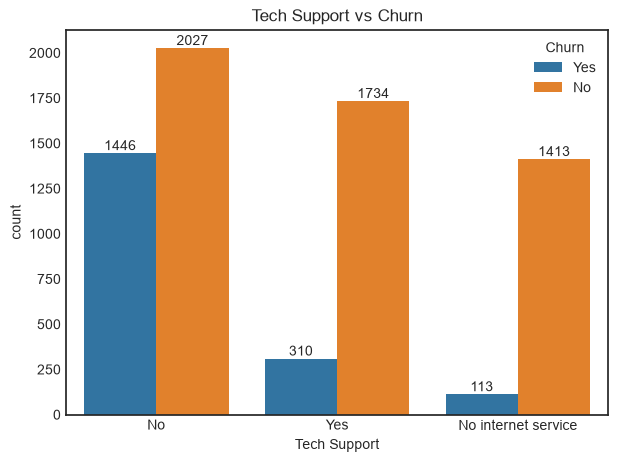

In [146]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='Tech Support', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Tech Support vs Churn")
plt.show()

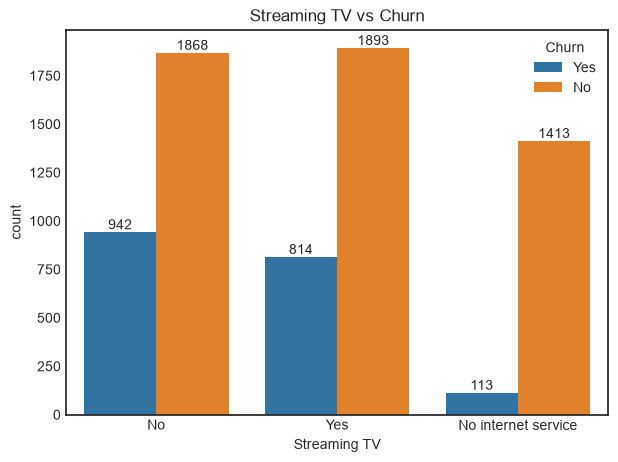

In [147]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='Streaming TV', hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Streaming TV vs Churn")
plt.show()

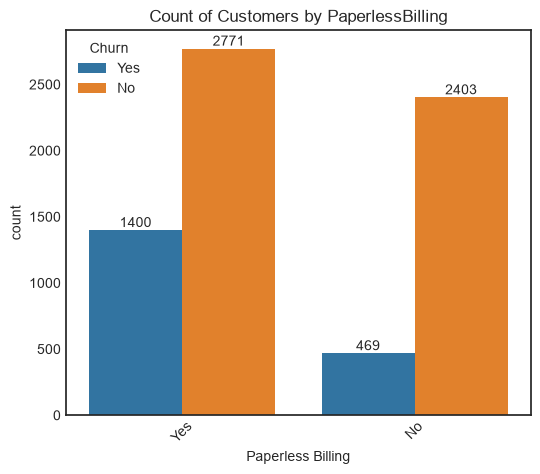

In [148]:
plt.figure(figsize = (6,5))
ax = sns.countplot(x = "Paperless Billing", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by PaperlessBilling")
plt.xticks(rotation = 45)
plt.show()

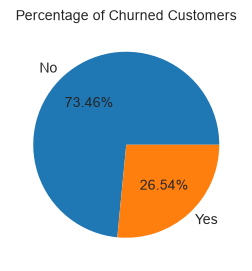

In [149]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn' : 'count'})

plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers", fontsize = 10)
plt.show()

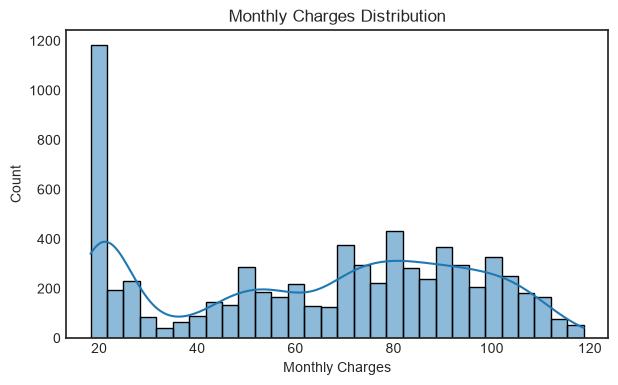

In [150]:
plt.figure(figsize=(7,4))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

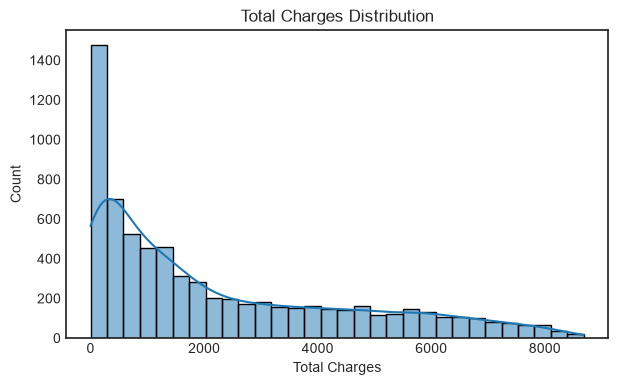

In [151]:
plt.figure(figsize=(7,4))
sns.histplot(df['Total Charges'], bins=30, kde=True)
plt.title("Total Charges Distribution")
plt.show()

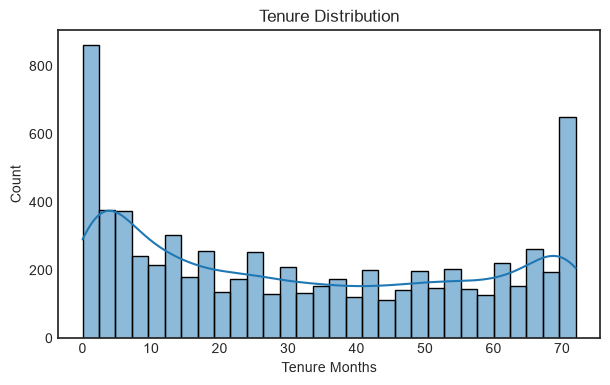

In [152]:
plt.figure(figsize=(7,4))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

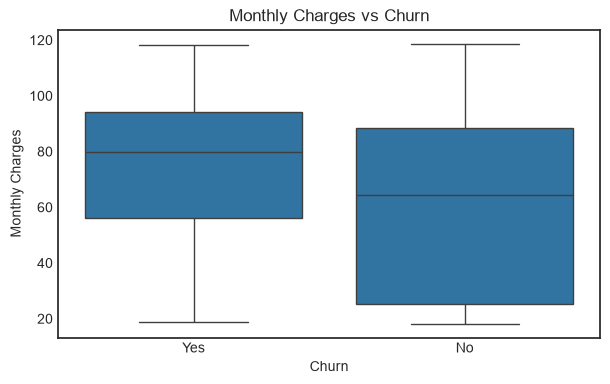

In [153]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='Monthly Charges')
plt.title("Monthly Charges vs Churn")
plt.show()

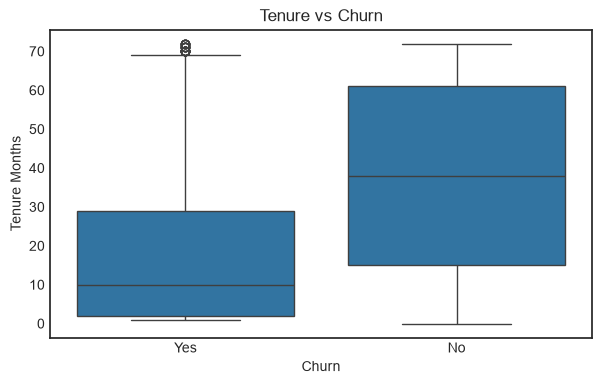

In [154]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='Tenure Months')
plt.title("Tenure vs Churn")
plt.show()

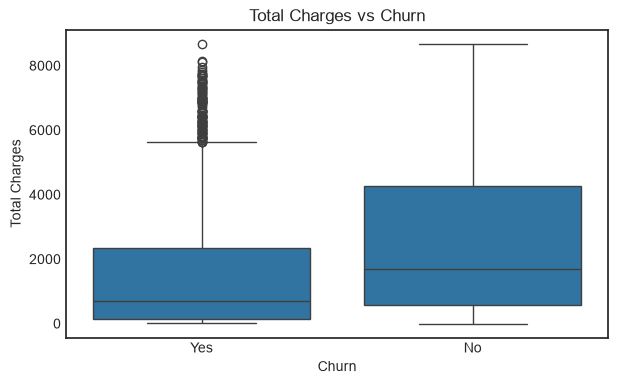

In [155]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='Total Charges')
plt.title("Total Charges vs Churn")
plt.show()

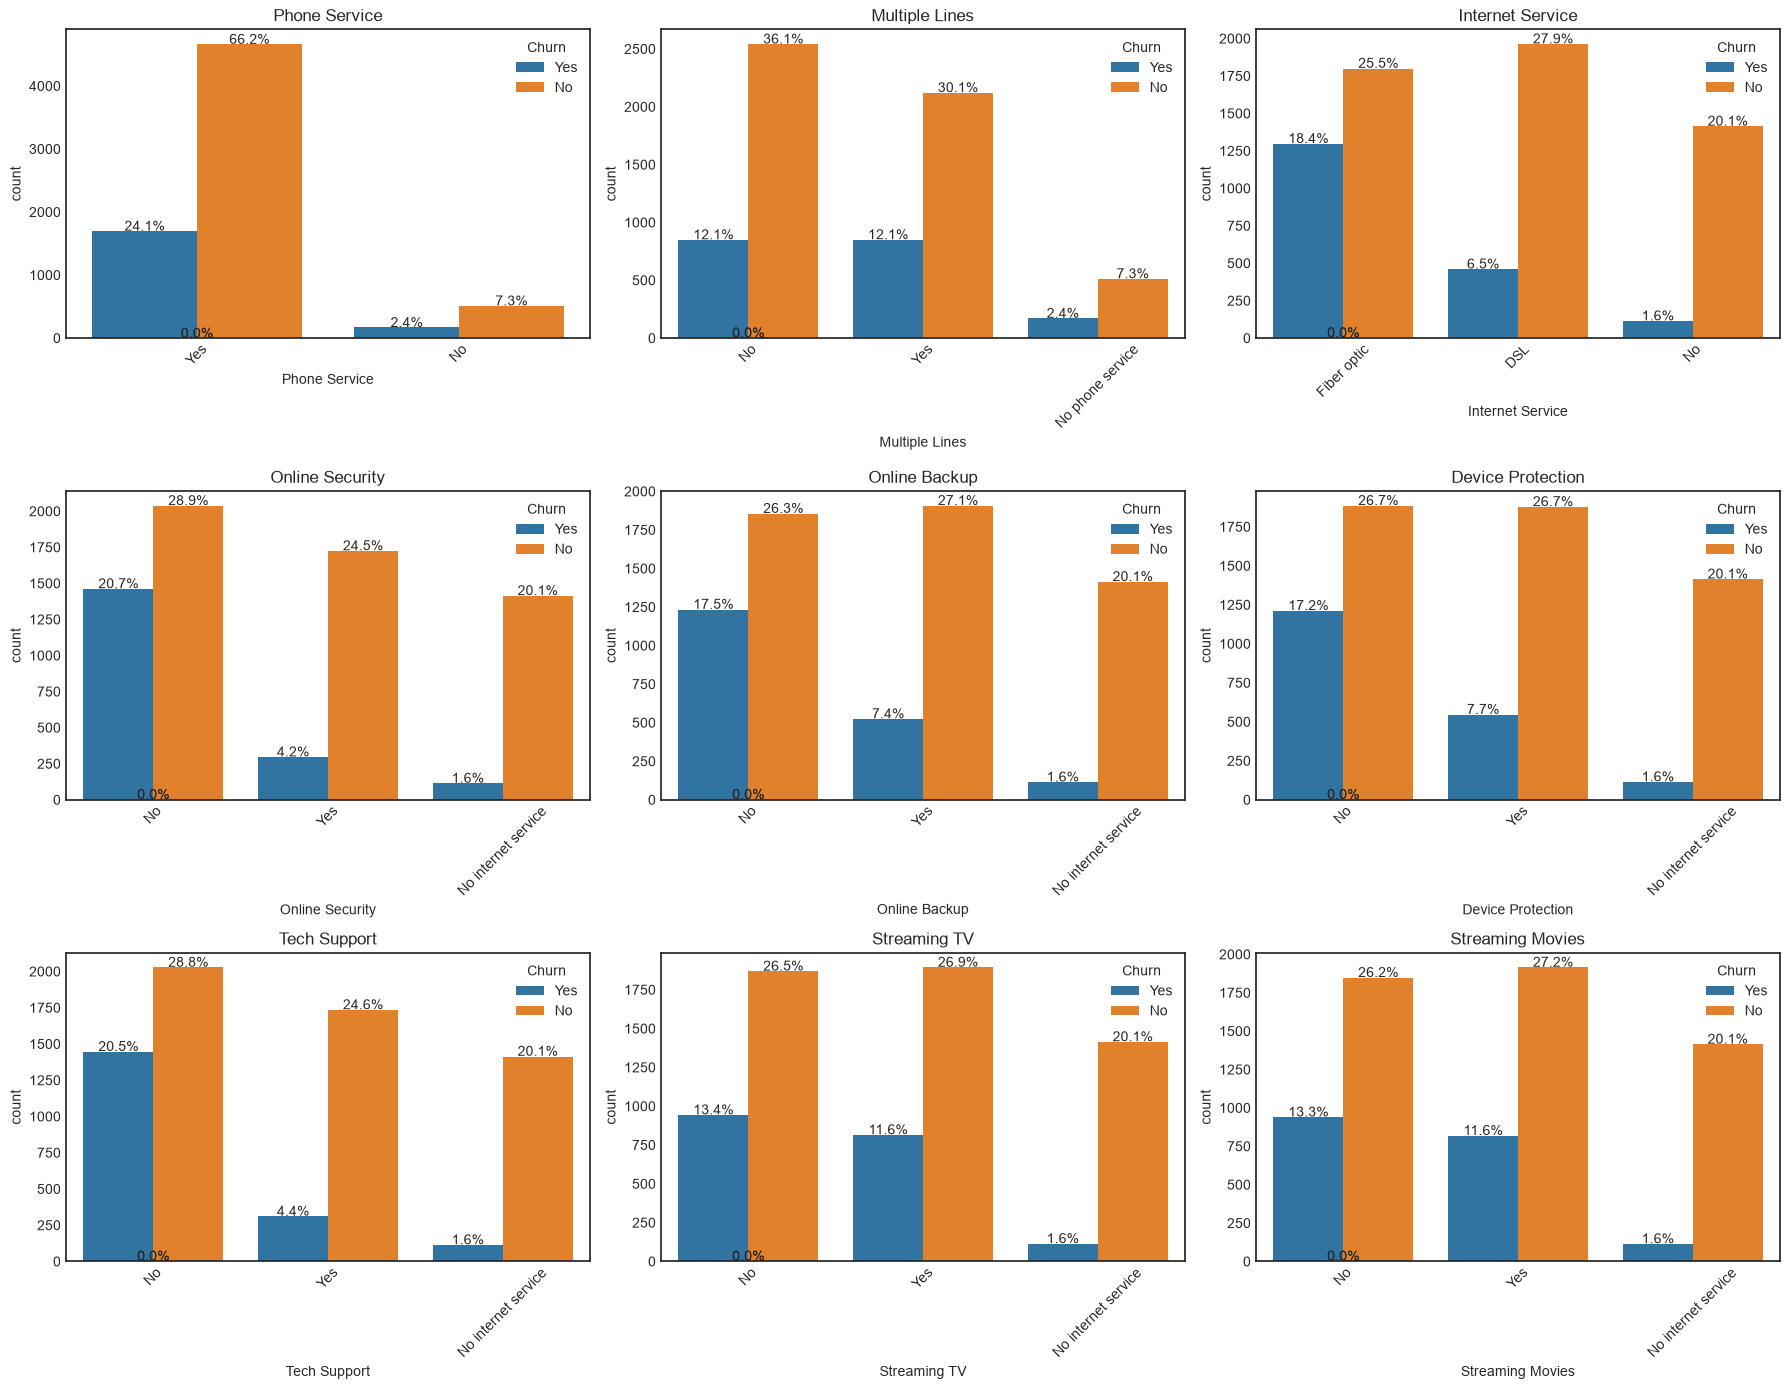

In [156]:
cols = ['Phone Service', 'Multiple Lines', 'Internet Service',
        'Online Security', 'Online Backup', 'Device Protection',
        'Tech Support', 'Streaming TV', 'Streaming Movies']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
axes = axes.flatten()

total_rows = len(df)

for i, col in enumerate(cols):
    ax = axes[i]
    order = df[col].value_counts().index 
    sns.countplot(x=col, data=df, ax=ax, order=order, hue = df["Churn"])

    for p in ax.patches:
        count = p.get_height()
        percentage = 100 * count / total_rows
        ax.text(p.get_x() + p.get_width() / 2, count + 5,
                f'{percentage:.1f}%', ha='center', fontsize=10)

    ax.set_title(col, fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Monthly Charges')

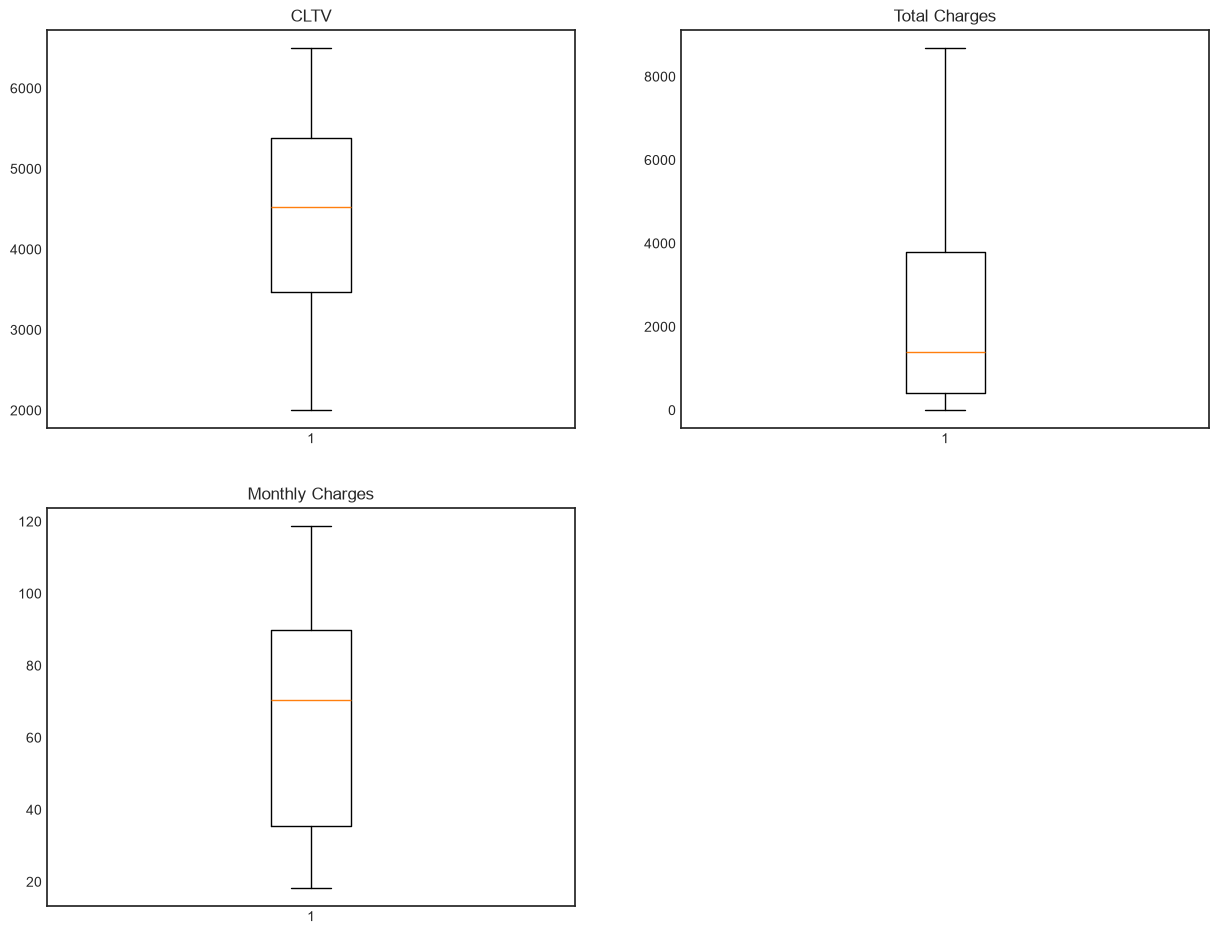

In [157]:
plt.figure(figsize = (15, 30))
plt.style.use('seaborn-v0_8-white')
ax=plt.subplot(521)
plt.boxplot(df['CLTV'])
ax.set_title('CLTV')
ax=plt.subplot(522)
plt.boxplot(df['Total Charges'])
ax.set_title('Total Charges')
ax=plt.subplot(523)
plt.boxplot(df['Monthly Charges'])
ax.set_title('Monthly Charges')

In [158]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [159]:
df.drop(columns=['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
                 'Lat Long', 'Latitude', 'Longitude', 'Streaming TV', 'Streaming Movies','Churn Reason'], inplace=True)

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Contract           7043 non-null   object 
 13  Paperless Billing  7043 non-null   object 
 14  Payment Method     7043 non-null   object 
 15  Monthly Charges    7043 non-null   float64
 16  Total Charges      7043 non-null   

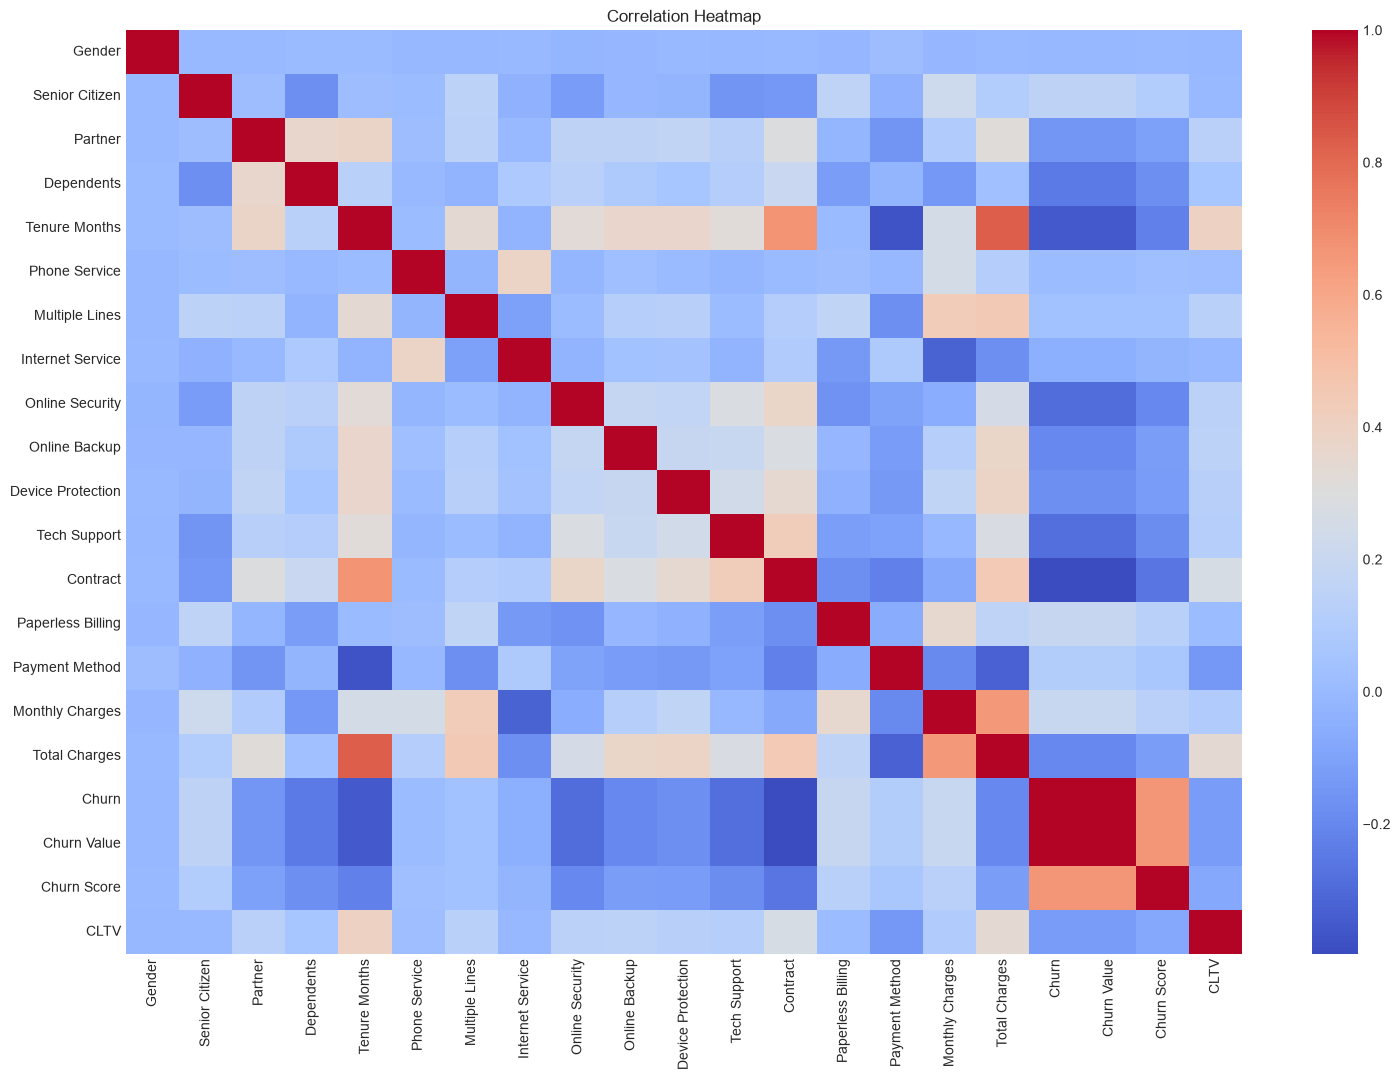

In [161]:
df_heat = df.copy()

le = LabelEncoder()

for col in df_heat.select_dtypes(include='object').columns:
    df_heat[col] = le.fit_transform(df_heat[col].astype(str))

plt.figure(figsize=(18,12))
sns.heatmap(df_heat.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [162]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='str')

In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Contract           7043 non-null   object 
 13  Paperless Billing  7043 non-null   object 
 14  Payment Method     7043 non-null   object 
 15  Monthly Charges    7043 non-null   float64
 16  Total Charges      7043 non-null   

In [164]:
le = LabelEncoder()

In [165]:
df["Gender"] = le.fit_transform(df["Gender"])
df["Senior Citizen"] = le.fit_transform(df["Senior Citizen"])
df["Partner"] = le.fit_transform(df["Partner"])
df["Dependents"] = le.fit_transform(df["Dependents"])
df["Phone Service"] = le.fit_transform(df["Phone Service"])
df["Multiple Lines"] = le.fit_transform(df["Multiple Lines"])
df["Internet Service"] = le.fit_transform(df["Internet Service"])
df["Online Security"] = le.fit_transform(df["Online Security"])
df["Online Backup"] = le.fit_transform(df["Online Backup"])
df["Device Protection"] = le.fit_transform(df["Device Protection"])
df["Tech Support"] = le.fit_transform(df["Tech Support"])
df["Contract"] = le.fit_transform(df["Contract"])
df["Paperless Billing"] = le.fit_transform(df["Paperless Billing"])
df["Payment Method"] = le.fit_transform(df["Payment Method"])
df["Churn"] = le.fit_transform(df["Churn"])

In [166]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   int64  
 1   Senior Citizen     7043 non-null   int64  
 2   Partner            7043 non-null   int64  
 3   Dependents         7043 non-null   int64  
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   int64  
 6   Multiple Lines     7043 non-null   int64  
 7   Internet Service   7043 non-null   int64  
 8   Online Security    7043 non-null   int64  
 9   Online Backup      7043 non-null   int64  
 10  Device Protection  7043 non-null   int64  
 11  Tech Support       7043 non-null   int64  
 12  Contract           7043 non-null   int64  
 13  Paperless Billing  7043 non-null   int64  
 14  Payment Method     7043 non-null   int64  
 15  Monthly Charges    7043 non-null   float64
 16  Total Charges      7043 non-null   

In [167]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(["CLTV"], axis =1), df["CLTV"], test_size = 0.3, random_state = 42)

### Linear Regression

In [168]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[-14.59,-56.65,-15.8 ,..., 27.46, 27.46, -0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['Gender','Senior Citizen','Partner',...,'Churn','Churn Value', 'Churn Score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3910
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)


In [169]:
lr_pred = lr_model.predict(X_test)
lr_acc = r2_score(lr_pred, y_test)
lr_acc

-4.01416696105993